<a href="https://colab.research.google.com/github/michael-sorani/LM4GeoAI/blob/main/Exercises/EX_1_Geo_Semantic_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 1: **Geo-Semantic Search**
### created by Etzion Harari | Geo-AI Course

[**https://github.com/EtzionR/LM4GeoAI**](https://github.com/EtzionR/LM4GeoAI)

## Prerequisites: pip install osmnx
[https://osmnx.readthedocs.io/en/stable/](https://osmnx.readthedocs.io/en/stable/)

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.3 MB/s eta 0:00:00


## Imports

In [1]:
from pandas.errors import SettingWithCopyWarning
from shapely import Point, Polygon
from time import time as get_time
from transformers import pipeline
from tqdm import tqdm

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import osmnx as ox
import numpy as np
import warnings
import folium

## Ignore pandas Warning

In [2]:
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

## Global variables: EPSG codes (define the spatial reference systems)

In [3]:
WGS84_UTM_31N = "EPSG:32631"
WGS84_GEO_DD  = "EPSG:4326"


## Define Food type place_type in OSM data

In [4]:
FOOD = {'restaurant', 'fast_food', 'cafe'}
FOOD

{'cafe', 'fast_food', 'restaurant'}

### Eiffel Tower Location
WGS84 GEO DD X = 2.2944492, Y = 48.8583088

WGS84 GEO UTM 31N X = 448248, Y = 5411944

In [5]:
EIFFEL = Point(448248, 5411944)

## Display Eiffel Tower on the map

In [6]:

eiffecl_wgs84_dd = gpd.GeoSeries([EIFFEL], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]

eiffel_x, eiffel_y = eiffecl_wgs84_dd.x, eiffecl_wgs84_dd.y

fmap = folium.Map(location=[eiffel_y,eiffel_x], zoom_start=15, width=1500, height=500)
folium.Marker([eiffel_y,eiffel_x], popup="Tour Eiffel", tooltip="Tour Eiffel").add_to(fmap)
fmap

## OSM search parameters

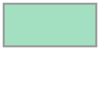

In [7]:
tags = {"amenity": True}

Paris = Polygon([(2.274507, 48.872479),
                 (2.351680, 48.872479),
                 (2.351680, 48.836947),
                 (2.274507, 48.836947),
                 (2.274507, 48.872479)])

Paris

## Load Data from OSM

In [8]:
START = get_time()

pois = ox.features_from_polygon(Paris, tags)

END = get_time()


print(f'Time to extarct data from OSM: {round(END-START,1)} seconds ({round((END-START)/60,1)} minutes)\n\n')

Time to extarct data from OSM: 12.8 seconds (0.2 minutes)




## Preprocess OSM data

In [9]:
pois = pois[['name', 'amenity', 'geometry']].dropna().rename(columns={'amenity':'place_type'}).to_crs(WGS84_UTM_31N)
pois['IsFood'] = pois.place_type.apply(lambda value: value in FOOD)

pois.head()

name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                                         geometry  IsFood  
element id                                                 
node    21662099   POINT (452320.712 5411188.723)   False  
        29434739   POINT (449155.089 5411637.554)   False  
        207782744  POINT (452027.373 5412910.533)   False  
        218117881  POINT (452300.497 5411757.428)   False  
        241110355  POINT (448589.838 5410098.839)   False

# --------------------------------------------------------------------

## Q1

#### Display the ratio of food type POIs (using "IsFood" column)

In [11]:
is_food_ratio = pois['IsFood'].value_counts(normalize=True)
is_food_ratio

,proportion
IsFood,
True,0.566988
False,0.433012


## Q2

#### Display the 10 most frequent **place_type**s

In [12]:
pois['place_type'].value_counts()[:10]

,count
place_type,
restaurant,3019
cafe,874
fast_food,813
bar,546
bank,301
bicycle_rental,283
school,282
pharmacy,236
place_of_worship,118


In [14]:
pois.loc[pois['IsFood'], 'place_type'].value_counts()[:10]

,count
place_type,
restaurant,3019
cafe,874
fast_food,813


## Q3

#### Calculate the distance (in meters) between each POI to Eiffel Tower

In [16]:
pois['distance_from_eiffel'] = pois['geometry'].distance(EIFFEL)
print(pois['distance_from_eiffel'].describe())
pois[['name', 'place_type', 'distance_from_eiffel']].head()

count    8300.000000
mean     2781.036206
std      1111.499794
min        10.872478
25%      1845.586534
50%      2962.028086
75%      3761.092263
max      4799.218606
Name: distance_from_eiffel, dtype: float64


name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                   distance_from_eiffel  
element id                               
node    21662099            4142.152038  
        29434739             957.454733  
        207782744           3901.005771  
        218117881           4056.789086  
        241110355           1876.558779

## Q4

#### 1) Select the 100 POIs closest to the Eiffel Tower and construct a new DataFrame containing only these POIs.

#### 2) Calculate the maximum distance (in meters) from the Eiffel Tower among the POIs in the selected DataFrame

In [17]:
eiffel_closest_pois = pois.sort_values('distance_from_eiffel').head(100)

max_eiffel_dist = eiffel_closest_pois['distance_from_eiffel'].max()
max_eiffel_dist

503.5064742719538

## Q5

#### Display the ratio of food type POIs, only for the 100 closest entities to Eiffel Tower (using "IsFood" column)

In [18]:
eiffel_closest_is_food_ratio = eiffel_closest_pois['IsFood'].value_counts(normalize=True)
eiffel_closest_is_food_ratio

,proportion
IsFood,
True,0.57
False,0.43


## Q6

#### Display the 100 closest entities to Eiffel Tower, using folium

In [23]:
eiffel_closest_map = folium.Map(location=[eiffel_y, eiffel_x], zoom_start=15, width=1500, height=800)

for idx, row in eiffel_closest_pois.iterrows():
    # Convert UTM geometry to WGS84 lat/lon for Folium
    poi_wgs84 = gpd.GeoSeries([row['geometry']], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]
    # Use centroid for both Point and Polygon geometries
    lat, lon = poi_wgs84.centroid.y, poi_wgs84.centroid.x
    name = row['name']
    folium.Marker([lat, lon], popup=name, tooltip=name).add_to(eiffel_closest_map)

eiffel_closest_map

## Q7

#### 1) Load the [multilingual-e5](https://huggingface.co/intfloat/multilingual-e5-large) language model using the **pipeline** interface for the **feature-extraction** task.

#### 2) Implement a function that takes a text string as input and returns a **single** embedding vector representing the text.

#### 3) Apply the function to a sample text and demonstrate the resulting embedding.



## Q8

#### Compute a text embedding for each place name (from the name column) corresponding to of the 100 closest entities to the Eiffel Tower (use the function from Q7.2).

## Q9

#### Using the function defined in Q7.2, compute the text embedding for the following free-text input:

``` sh
QUERY = "I want something to eat"

```

## Q10

#### 1) Compute the distance between the query embedding and each place-name embedding using the **L1 norm**.

#### 2) Compute the distance between the query embedding and each place-name embedding using the **L2 norm**.

#### 3) Compute the distance between the query embedding and each place-name embedding using **cosine similarity** based distance.

#### 4) As a baseline metric, generate a random value $r \sim U[0,1]$ for each place name.

# ------

## Additional details on the distance matrices are provided below:

$x$ - Embedding vector of given 100 POI place name

$q$ - Embedding vector of the input Query

$x,q \in \mathbb{R}^{n}$


distance functions:

 - L1 (Manhattan Distance): $L1(x, q) = \frac{1}{n}\sum_{i=1}^{n}|x_i-q_i|$
 - L2 (Euclidean Distance): $L2(x, q) = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-q_i)^{2}}$
 - CS (Cosine Similarity): $CS(x, q) = \frac{x^{t}q}{||x|| \cdot ||q||} = \frac{\sum_{i=1}^{n}(x_i \cdot q_i)}{\sqrt{\sum_{i=1}^{n}x_i^2} \cdot \sqrt{\sum_{i=1}^{n}q_i^2}} $


##

## Q11

#### 1) For each $K \in \{ 5, 10, 25, 50, 100\}$, compute the **Precision@K** for the top-K closest places according to each distance metric (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Display the output results in as a pandas dataframe table




## Q12

#### 1) Compute **Precision@K** for each $K \in \{5,6,7, \cdot \cdot \cdot, 98, 99, 100 \}$ across all distance metrics (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Create a figure that visualizes **Precision@K** as a function of K for each distance metric.

#### 3) Add to the figure the proportion of food-related places among the 100 closest points of interest to the Eiffel Tower (as computed in Q5).

#### 4) Interpret and explain the results presented in the figure.


## Q13

#### Identify the distance metric that achieves the highest **Precision@K** for $K<10$.

## Q14

#### Visualize the top 10 results according to the metric selected in Q13 on a Folium map, displayed alongside the Eiffel Tower.

## Q - Bonus

#### Compute **Precision@K** for $K=10$ among the 100 closest points of interest (POIs) to the Eiffel Tower using the L2 norm.

#### Perform this evaluation using text embeddings generated from the following language models:

- [google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased)

- [almanach/camembert-large](https://huggingface.co/almanach/camembert-large)

- [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large)

#### Analyze and interpret the results, highlighting differences in performance across the models.

# Bon appétit!

Create by Etzion Harari | Geo-AI Course | [https://github.com/EtzionR/LM4GeoAI](https://github.com/EtzionR/LM4GeoAI)